In [ ]:
!pip install -q lizard xgboost lightgbm catboost shap scikit-learn pandas matplotlib seaborn tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 1.6 MB/s eta 0:00:00


In [ ]:
import json
import re
import numpy as np
import pandas as pd
import lizard
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import math
from collections import Counter

from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, f1_score
from sklearn.feature_selection import SelectKBest, mutual_info_classif, SelectFromModel

warnings.filterwarnings('ignore')

# =====================================================================
# PHẦN 1: BỘ TRÍCH XUẤT ĐẶC TRƯNG V8 (ANTI-OVERFIT & SOTA METRICS)
# =====================================================================
class CppFeatureExtractorV8:
    def __init__(self):
        self.string_pattern = re.compile(r'".*?(?<!\\)"|\'.*?(?<!\\)\'')
        self.comment_line_pattern = re.compile(r'//.*')
        self.comment_block_pattern = re.compile(r'/\*.*?\*/', re.DOTALL)

        self.include_pattern = re.compile(r'#include\s*[<"].*[>"]')
        self.macro_pattern = re.compile(r'#define\s+')
        self.bits_stdc_pattern = re.compile(r'bits/stdc\+\+\.h')
        self.fast_io_pattern = re.compile(r'ios_base::sync_with_stdio|cin\.tie')

        self.modern_cpp_pattern = re.compile(r'\b(auto|nullptr|unique_ptr|shared_ptr|constexpr|lambda)\b')
        self.const_pattern = re.compile(r'\b(const|constexpr)\b')
        self.exception_pattern = re.compile(r'\b(try|catch|throw)\b')
        self.single_char_var_pattern = re.compile(r'\b[a-zA-Z]\b')

        # Regex hỗ trợ tính Halstead (Toán tử & Toán hạng)
        self.operators_pattern = re.compile(r'(\+|-|\*|/|%|=|==|!=|<|>|<=|>=|&&|\|\||!|&|\||\^|~|<<|>>|\+\+|--|->|\.|::|\?|:)')
        self.keywords = {'int', 'void', 'if', 'else', 'while', 'for', 'return', 'class', 'public', 'private', 'struct', 'bool', 'char', 'float', 'double', 'std', 'cout', 'cin', 'endl', 'break', 'continue'}

    def calculate_entropy(self, text):
        if not text: return 0.0
        prob = [float(c) / len(text) for c in dict(Counter(text)).values()]
        return -sum(p * math.log2(p) for p in prob)

    def calculate_bigram_entropy(self, text):
        if len(text) < 2: return 0.0
        bigrams = [text[i:i+2] for i in range(len(text)-1)]
        prob = [float(c) / len(bigrams) for c in dict(Counter(bigrams)).values()]
        return -sum(p * math.log2(p) for p in prob)

    def calculate_halstead_metrics(self, pure_code, identifiers):
        # N1, n1: Operators (Toán tử và từ khóa)
        ops = self.operators_pattern.findall(pure_code)
        kw_found = [w for w in re.findall(r'\b[a-zA-Z_]\w*\b', pure_code) if w in self.keywords]
        all_operators = ops + kw_found

        N1 = len(all_operators)
        n1 = len(set(all_operators))

        # N2, n2: Operands (Biến, hàm, chuỗi, số)
        strings = self.string_pattern.findall(pure_code)
        numbers = re.findall(r'\b\d+(\.\d+)?\b', pure_code)
        all_operands = identifiers + strings + numbers

        N2 = len(all_operands)
        n2 = len(set(all_operands))

        # Tính toán Halstead
        n = n1 + n2 # Vocabulary
        N = N1 + N2 # Length

        Volume = N * math.log2(n) if n > 0 else 0
        Difficulty = (n1 / 2) * (N2 / n2) if n2 > 0 else 0
        Effort = Difficulty * Volume
        Bugs = Volume / 3000

        return Volume, Difficulty, Effort, Bugs

    def extract(self, code_raw):
        features = {}
        lines = code_raw.split('\n')
        total_chars = len(code_raw)
        pure_lines = [l for l in lines if l.strip() and not l.strip().startswith('//')]
        total_loc = len(pure_lines) if len(pure_lines) > 0 else 1

        line_comments = self.comment_line_pattern.findall(code_raw)
        block_comments = self.comment_block_pattern.findall(code_raw)
        comments_text = "\n".join(line_comments + block_comments)

        pure_code = self.string_pattern.sub('', code_raw)
        pure_code = self.comment_block_pattern.sub('', pure_code)
        pure_code = self.comment_line_pattern.sub('', pure_code)

        # --- [A] LAYOUT & FORMATTING ---
        features['comment_ratio'] = len(comments_text) / total_chars if total_chars > 0 else 0
        features['empty_line_ratio'] = sum(1 for line in lines if not line.strip()) / max(1, len(lines))

        line_lengths = [len(l.strip()) for l in pure_lines]
        features['avg_line_length'] = np.mean(line_lengths) if line_lengths else 0
        features['max_line_length'] = np.max(line_lengths) if line_lengths else 0

        spaces = code_raw.count(' ')
        tabs = code_raw.count('\t')
        features['tab_vs_space_ratio'] = tabs / (spaces + tabs) if (spaces + tabs) > 0 else 0
        features['trailing_space_ratio'] = sum(1 for l in lines if l.endswith(' ') or l.endswith('\t')) / max(1, len(lines))

        kr_brace = len(re.findall(r'\S\s*\{', pure_code))
        allman_brace = len(re.findall(r'^\s*\{', pure_code, re.MULTILINE))
        total_braces = kr_brace + allman_brace
        allman_ratio = allman_brace / total_braces if total_braces > 0 else 0.5
        features['brace_style_consistency'] = abs(allman_ratio - 0.5) * 2 # 0: mixed, 1: consistent

        # --- [B] NAMING CONVENTIONS ---
        identifiers = re.findall(r'\b[a-zA-Z_][a-zA-Z0-9_]*\b', pure_code)
        custom_ids = [w for w in identifiers if w not in self.keywords]

        if custom_ids:
            id_lengths = [len(w) for w in custom_ids]
            features['avg_identifier_length'] = np.mean(id_lengths)
            features['identifier_length_variance'] = np.var(id_lengths)
            features['single_char_var_ratio'] = len(self.single_char_var_pattern.findall(pure_code)) / len(custom_ids)
            features['unique_identifier_ratio'] = len(set(custom_ids)) / len(custom_ids)
        else:
            features['avg_identifier_length'] = 0
            features['identifier_length_variance'] = 0
            features['single_char_var_ratio'] = 0
            features['unique_identifier_ratio'] = 0

        features['keyword_to_identifier_ratio'] = len([w for w in identifiers if w in self.keywords]) / max(1, len(custom_ids))

        # --- [C] STRUCTURAL COMPLEXITY (Halstead + Cyclomatic) ---
        analysis = lizard.analyze_file.analyze_source_code("test.cpp", code_raw)
        if analysis.function_list:
            cc_list = [f.cyclomatic_complexity for f in analysis.function_list]
            features['avg_cyclomatic_complexity'] = np.mean(cc_list)
            features['num_functions'] = len(analysis.function_list)
            features['avg_function_loc'] = np.mean([f.end_line - f.start_line for f in analysis.function_list])
        else:
            features['avg_cyclomatic_complexity'] = 1.0
            features['num_functions'] = 0
            features['avg_function_loc'] = 0

        # Tính toán Halstead Metrics
        V, D, E, B = self.calculate_halstead_metrics(pure_code, custom_ids)
        features['halstead_volume'] = V
        features['halstead_difficulty'] = D
        features['halstead_effort'] = E
        features['halstead_bugs'] = B

        # Maintainability Index
        MI = 171 - 5.2 * math.log(max(1, V)) - 0.23 * features['avg_cyclomatic_complexity'] - 16.2 * math.log(max(1, total_loc))
        features['maintainability_index'] = max(0, MI)
        features['code_to_comment_ratio'] = total_loc / max(1, len(comments_text.split('\n')))

        # Độ sâu lồng nhau (Nesting depth heuristic)
        depth, max_depth = 0, 0
        for char in pure_code:
            if char == '{': depth += 1; max_depth = max(max_depth, depth)
            elif char == '}': depth = max(0, depth - 1)
        features['max_nesting_depth'] = max_depth

        # --- [D] CODING HABITS & IDIOMS ---
        features['total_includes'] = len(self.include_pattern.findall(code_raw))
        features['has_bits_stdc'] = 1 if self.bits_stdc_pattern.search(code_raw) else 0
        features['macro_count'] = len(self.macro_pattern.findall(code_raw))

        total_words = len(re.findall(r'\b\w+\b', pure_code))
        features['modern_cpp_ratio'] = len(self.modern_cpp_pattern.findall(pure_code)) / max(1, total_words)
        features['const_usage_ratio'] = len(self.const_pattern.findall(pure_code)) / max(1, total_words)

        features['has_fast_io'] = 1 if self.fast_io_pattern.search(pure_code) else 0

        count_endl = pure_code.count('endl')
        count_n = pure_code.count('\\n')
        features['newline_style_ratio'] = count_n / max(1, (count_n + count_endl))

        # --- [E] INFORMATION THEORY ---
        features['shannon_entropy'] = self.calculate_entropy(pure_code)
        features['bigram_entropy'] = self.calculate_bigram_entropy(pure_code)

        # Whitespace pattern entropy
        spaces_pattern = "".join(['S' if c == ' ' else 'T' if c == '\t' else 'N' if c == '\n' else '' for c in code_raw])
        features['whitespace_entropy'] = self.calculate_entropy(spaces_pattern)

        return features

def strip_metadata_headers(code_raw):
    """ XÓA BỎ DATA LEAKAGE TỪ METADATA HEADER CỦA AI """
    # Xóa các dòng comment đầu file có chứa chữ DATASET, MODEL, GEMINI, GPT...
    lines = code_raw.split('\n')
    cleaned_lines = []
    header_passed = False

    for line in lines:
        if not header_passed:
            if line.strip().startswith('//') and any(kw in line.upper() for kw in ['DATASET', 'MODEL', 'GEMINI', 'GPT', 'CATEGORY']):
                continue # Bỏ qua dòng này (leakage)
            if line.strip() != '':
                header_passed = True # Đã hết vùng header
        cleaned_lines.append(line)

    return "\n".join(cleaned_lines)

Dựa vào đoạn mã bạn cung cấp, class `CppFeatureExtractorV8` đang trích xuất tổng cộng **32 đặc trưng (features)** từ mã nguồn C++.



### **[A] Layout & Formatting (Định dạng & Bố cục) - 7 đặc trưng**
1. `comment_ratio`: Tỷ lệ comment trên tổng số ký tự.
2. `empty_line_ratio`: Tỷ lệ dòng trống trên tổng số dòng.
3. `avg_line_length`: Chiều dài trung bình của các dòng code.
4. `max_line_length`: Chiều dài tối đa của một dòng code.
5. `tab_vs_space_ratio`: Tỷ lệ sử dụng Tab so với Space.
6. `trailing_space_ratio`: Tỷ lệ các dòng có khoảng trắng thừa ở cuối.
7. `brace_style_consistency`: Độ nhất quán trong phong cách đặt dấu ngoặc nhọn (K&R vs Allman).

### **[B] Naming Conventions (Quy tắc đặt tên) - 5 đặc trưng**
8. `avg_identifier_length`: Chiều dài trung bình của các định danh (tên biến, hàm...).
9. `identifier_length_variance`: Phương sai chiều dài của các định danh.
10. `single_char_var_ratio`: Tỷ lệ sử dụng biến có 1 ký tự.
11. `unique_identifier_ratio`: Tỷ lệ định danh độc nhất.
12. `keyword_to_identifier_ratio`: Tỷ lệ từ khóa C++ so với các định danh tự đặt.

### **[C] Structural Complexity (Độ phức tạp cấu trúc) - 10 đặc trưng**
13. `avg_cyclomatic_complexity`: Độ phức tạp Cyclomatic trung bình của các hàm.
14. `num_functions`: Tổng số lượng hàm.
15. `avg_function_loc`: Số dòng code trung bình của một hàm.
16. `halstead_volume`: Chỉ số Khối lượng (Volume) theo Halstead.
17. `halstead_difficulty`: Chỉ số Độ khó (Difficulty) theo Halstead.
18. `halstead_effort`: Chỉ số Nỗ lực (Effort) theo Halstead.
19. `halstead_bugs`: Ước lượng số lượng lỗi (Bugs) theo Halstead.
20. `maintainability_index`: Chỉ số khả năng bảo trì.
21. `code_to_comment_ratio`: Tỷ lệ số dòng code thực tế so với số dòng comment.
22. `max_nesting_depth`: Độ sâu lồng nhau tối đa (ví dụ: các vòng lặp, câu lệnh if lồng nhau).

### **[D] Coding Habits & Idioms (Thói quen lập trình) - 7 đặc trưng**
23. `total_includes`: Tổng số lượng thư viện được include.
24. `has_bits_stdc`: Có sử dụng thư viện gom `bits/stdc++.h` hay không (1 hoặc 0).
25. `macro_count`: Số lượng macro (`#define`) được sử dụng.
26. `modern_cpp_ratio`: Tỷ lệ sử dụng các từ khóa C++ hiện đại (auto, nullptr, lambda...).
27. `const_usage_ratio`: Tỷ lệ sử dụng từ khóa `const` hoặc `constexpr`.
28. `has_fast_io`: Có sử dụng các câu lệnh tối ưu I/O (như `ios_base::sync_with_stdio`) hay không (1 hoặc 0).
29. `newline_style_ratio`: Thói quen xuống dòng (Tỷ lệ dùng `\n` so với `endl`).

### **[E] Information Theory (Lý thuyết thông tin) - 3 đặc trưng**
30. `shannon_entropy`: Độ hỗn loạn (Entropy) tính trên toàn bộ code thuần.
31. `bigram_entropy`: Độ hỗn loạn tính trên các cặp ký tự liền kề (Bigram).
32. `whitespace_entropy`: Độ hỗn loạn của các khoảng trắng (Space, Tab, Newline).

In [ ]:
file_path = "/content/drive/MyDrive/LVTN: AI code detection/AI Detection Dataset/train_data_10_model_AI.jsonl"
print("📥 1. ĐANG LOAD, LÀM SẠCH VÀ TRÍCH XUẤT DỮ LIỆU...")

with open(file_path, "r", encoding="utf-8") as f:
    dataset = [json.loads(line) for line in f]

extractor = CppFeatureExtractorV8()
extracted_data = []

for item in tqdm(dataset, desc="Extracting Features"):
    # 1. Strip Metadata Header (Chống Leakage)
    clean_code = strip_metadata_headers(item['code'])

    # 2. Trích xuất
    features = extractor.extract(clean_code)
    features['label'] = 1 if item['label'] == 'AI' else 0
    extracted_data.append(features)

df_all = pd.DataFrame(extracted_data).fillna(0)

# Chia dữ liệu cơ bản
X = df_all.drop(columns=['label'])
y = df_all['label']

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

print(f"Tổng số Features sau khi trích xuất: {X_train.shape[1]}")

📥 1. ĐANG LOAD, LÀM SẠCH VÀ TRÍCH XUẤT DỮ LIỆU...


Extracting Features:   0%|          | 0/6280 [00:00<?, ?it/s]

Tổng số Features sau khi trích xuất: 32


In [ ]:
test_indices = X_test.index
test_records = [dataset[i] for i in test_indices]

with open('/content/drive/MyDrive/LVTN: AI code detection/Saved_Models/test_set_for_bert.jsonl', 'w') as f:
    for record in test_records:
        f.write(json.dumps(record) + '\n')

print(f"Đã lưu {len(test_records)} samples cho BERT inference")

Đã lưu 1256 samples cho BERT inference


In [ ]:
print("\n🛡️ 2. CHẠY PIPELINE FEATURE SELECTION (3 TẦNG LỌC)")
print("-" * 60)

# Scale dữ liệu trước khi chọn (Cần thiết cho L1)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_val_scaled = pd.DataFrame(scaler.transform(X_val), columns=X_val.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

# --- TẦNG 1: LỌC TƯƠNG QUAN (CORRELATION FILTER) ---
corr_matrix = X_train_scaled.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop_corr = [column for column in upper.columns if any(upper[column] > 0.85)] # Ngưỡng 0.85

print(f"Tầng 1: Đã loại {len(to_drop_corr)} features do đa cộng tuyến (r > 0.85).")
X_train_t1 = X_train_scaled.drop(columns=to_drop_corr)

# --- TẦNG 2: SELECT K-BEST (MUTUAL INFORMATION) ---
# Chọn top 20 features có lượng thông tin tốt nhất
selector_kbest = SelectKBest(score_func=mutual_info_classif, k=min(20, X_train_t1.shape[1]))
X_train_t2_arr = selector_kbest.fit_transform(X_train_t1, y_train)
selected_kbest_cols = X_train_t1.columns[selector_kbest.get_support()]

print(f"Tầng 2: Giữ lại {len(selected_kbest_cols)} features dựa trên Mutual Information.")
X_train_t2 = pd.DataFrame(X_train_t2_arr, columns=selected_kbest_cols)

# --- TẦNG 3: LASSO REGULARIZATION (L1) ---
lasso = LogisticRegression(penalty='l1', solver='liblinear', random_state=42, C=0.5)
selector_l1 = SelectFromModel(lasso)
selector_l1.fit(X_train_t2, y_train)
final_features = X_train_t2.columns[selector_l1.get_support()]

print(f"Tầng 3: Chốt hạ {len(final_features)} features quan trọng nhất qua Lasso L1.")
print("\n=> DANH SÁCH FEATURES CUỐI CÙNG SẼ HUẤN LUYỆN:")
print(list(final_features))

# Áp dụng bộ features này cho tất cả các tập
X_train_final = X_train_scaled[final_features]
X_val_final = X_val_scaled[final_features]
X_test_final = X_test_scaled[final_features]


🛡️ 2. CHẠY PIPELINE FEATURE SELECTION (3 TẦNG LỌC)
------------------------------------------------------------
Tầng 1: Đã loại 3 features do đa cộng tuyến (r > 0.85).
Tầng 2: Giữ lại 20 features dựa trên Mutual Information.
Tầng 3: Chốt hạ 20 features quan trọng nhất qua Lasso L1.

=> DANH SÁCH FEATURES CUỐI CÙNG SẼ HUẤN LUYỆN:
['empty_line_ratio', 'avg_line_length', 'max_line_length', 'tab_vs_space_ratio', 'brace_style_consistency', 'avg_identifier_length', 'identifier_length_variance', 'single_char_var_ratio', 'unique_identifier_ratio', 'keyword_to_identifier_ratio', 'avg_cyclomatic_complexity', 'avg_function_loc', 'halstead_volume', 'halstead_difficulty', 'maintainability_index', 'code_to_comment_ratio', 'max_nesting_depth', 'total_includes', 'macro_count', 'whitespace_entropy']


In [ ]:
import lightgbm as lgb

print("\n🧠 3. HUẤN LUYỆN MODEL (STRICT REGULARIZATION)")
print("-" * 60)

imbalance_ratio = float((y_train == 0).sum()) / (y_train == 1).sum()

# Khai báo model (Đã cập nhật API mới)
models = {
    "XGBoost_Regulated": xgb.XGBClassifier(
        use_label_encoder=False, eval_metric='logloss', random_state=42,
        scale_pos_weight=imbalance_ratio,
        max_depth=5,
        min_child_weight=5,
        subsample=0.8,
        colsample_bytree=0.8,
        learning_rate=0.05,
        n_estimators=300,
        early_stopping_rounds=30  # <-- CHUYỂN VÀO ĐÂY CHO XGBOOST
    ),
    "LightGBM_Regulated": lgb.LGBMClassifier(
        random_state=42, verbose=-1, class_weight='balanced',
        max_depth=5, num_leaves=20,
        min_child_samples=20, subsample=0.8, colsample_bytree=0.8,
        learning_rate=0.05, n_estimators=300
    ),
    "RandomForest_Regulated": RandomForestClassifier(
        random_state=42, class_weight='balanced',
        max_depth=6, min_samples_split=10, min_samples_leaf=5,
        n_estimators=300
    )
}

best_val_score = 0
best_model_name = ""
final_model = None

for name, model in models.items():
    # Fit model với cú pháp mới
    if name == "XGBoost_Regulated":
        # XGBoost chỉ cần eval_set và verbose ở đây vì early_stopping đã khai báo ở trên
        model.fit(X_train_final, y_train,
                  eval_set=[(X_val_final, y_val)],
                  verbose=False)

    elif name == "LightGBM_Regulated":
        # LightGBM bản mới yêu cầu dùng callbacks cho early stopping
        model.fit(X_train_final, y_train,
                  eval_set=[(X_val_final, y_val)],
                  callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)])

    else: # Dành cho RandomForest (không hỗ trợ early stopping nội tại theo cách này)
        model.fit(X_train_final, y_train)

    # Đánh giá trên Validation
    y_val_pred = model.predict(X_val_final)
    val_f1 = f1_score(y_val, y_val_pred)

    # Kiểm tra Overfit tức thời trên Train
    train_acc = accuracy_score(y_train, model.predict(X_train_final))
    print(f"[{name}] Train Acc: {train_acc:.4f} | Val F1: {val_f1:.4f}")

    if train_acc == 1.0:
        print("   ⚠️ Vẫn có dấu hiệu memorize 100% data!")

    if val_f1 > best_val_score:
        best_val_score = val_f1
        best_model_name = name
        final_model = model

print(f"\n=> 🏆 MODEL CHIẾN THẮNG: {best_model_name}")


🧠 3. HUẤN LUYỆN MODEL (STRICT REGULARIZATION)
------------------------------------------------------------
[XGBoost_Regulated] Train Acc: 0.9936 | Val F1: 0.9684
[LightGBM_Regulated] Train Acc: 0.9995 | Val F1: 0.9738
[RandomForest_Regulated] Train Acc: 0.9594 | Val F1: 0.9515

=> 🏆 MODEL CHIẾN THẮNG: LightGBM_Regulated



📈 4. BÁO CÁO KẾT QUẢ TRÊN TẬP TEST KÍN (20%)
Accuracy Tập TRAIN: 99.95%
Accuracy Tập TEST : 96.26%

💡 KẾT LUẬN OVERFIT: Chênh lệch Train-Test là 3.69%
⚠️ Vẫn còn hơi Overfit (chênh lệch > 3%), bạn có thể cần tăng penalty thêm ở phần Model.

BẢNG ĐÁNH GIÁ CHI TIẾT (Classification Report):
              precision    recall  f1-score   support

   Human (0)       0.96      0.96      0.96       628
      AI (1)       0.96      0.96      0.96       628

    accuracy                           0.96      1256
   macro avg       0.96      0.96      0.96      1256
weighted avg       0.96      0.96      0.96      1256



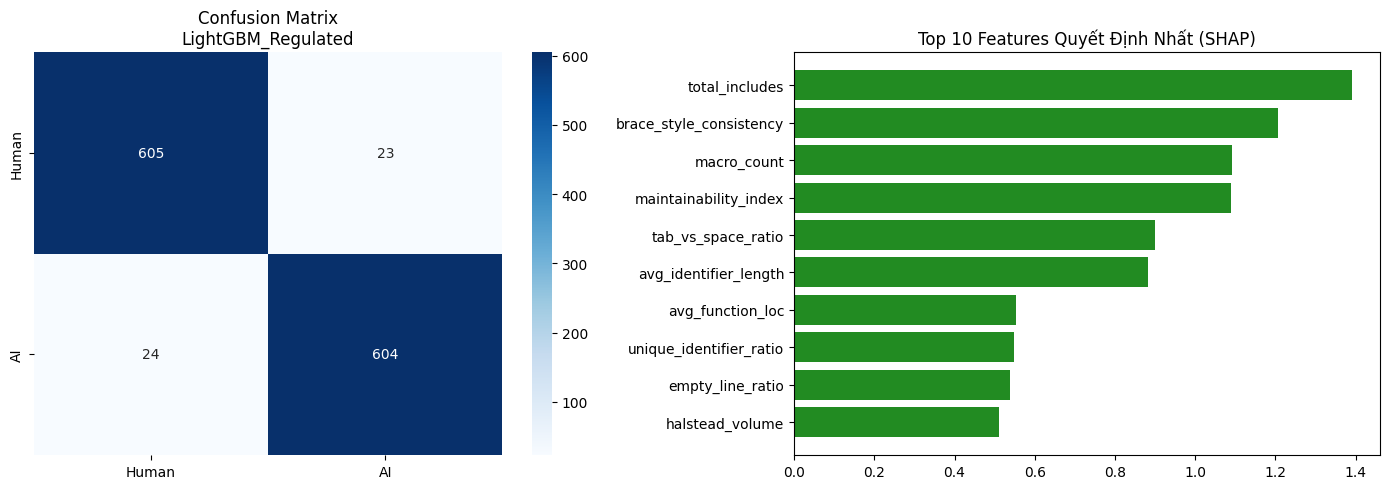

In [ ]:
print("\n" + "="*60)
print("📈 4. BÁO CÁO KẾT QUẢ TRÊN TẬP TEST KÍN (20%)")
print("="*60)

y_train_pred = final_model.predict(X_train_final)
y_test_pred  = final_model.predict(X_test_final)

acc_train = accuracy_score(y_train, y_train_pred)
acc_test  = accuracy_score(y_test, y_test_pred)

print(f"Accuracy Tập TRAIN: {acc_train*100:.2f}%")
print(f"Accuracy Tập TEST : {acc_test*100:.2f}%")

acc_diff = acc_train - acc_test
print(f"\n💡 KẾT LUẬN OVERFIT: Chênh lệch Train-Test là {abs(acc_diff)*100:.2f}%")
if acc_diff > 0.03:
    print("⚠️ Vẫn còn hơi Overfit (chênh lệch > 3%), bạn có thể cần tăng penalty thêm ở phần Model.")
elif acc_train > 0.99:
    print("⚠️ Mô hình đạt độ chính xác quá cao (>99%). Cần kiểm tra lại dữ liệu xem có điểm leakage nào sót lại không.")
else:
    print("✅ XUẤT SẮC! Mô hình có tính tổng quát hóa cao, đã chữa dứt điểm bệnh Memorization.")

print("\nBẢNG ĐÁNH GIÁ CHI TIẾT (Classification Report):")
print(classification_report(y_test, y_test_pred, target_names=["Human (0)", "AI (1)"]))

# Vẽ biểu đồ
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Human', 'AI'], yticklabels=['Human', 'AI'])
plt.title(f'Confusion Matrix\n{best_model_name}')

plt.subplot(1, 2, 2)
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test_final)
if isinstance(shap_values, list):
    shap_values = shap_values[1] # Dành cho một số phiên bản LightGBM/RF
mean_shap = np.abs(shap_values).mean(axis=0)
shap_indices = np.argsort(mean_shap)[-10:]
plt.barh(range(len(shap_indices)), mean_shap[shap_indices], color='forestgreen')
plt.yticks(range(len(shap_indices)), [X_test_final.columns[i] for i in shap_indices])
plt.title('Top 10 Features Quyết Định Nhất (SHAP)')

plt.tight_layout()
plt.show()


🔍 TRỰC QUAN HÓA MỨC ĐỘ QUAN TRỌNG CỦA ĐẶC TRƯNG (FEATURE IMPORTANCE)
------------------------------------------------------------


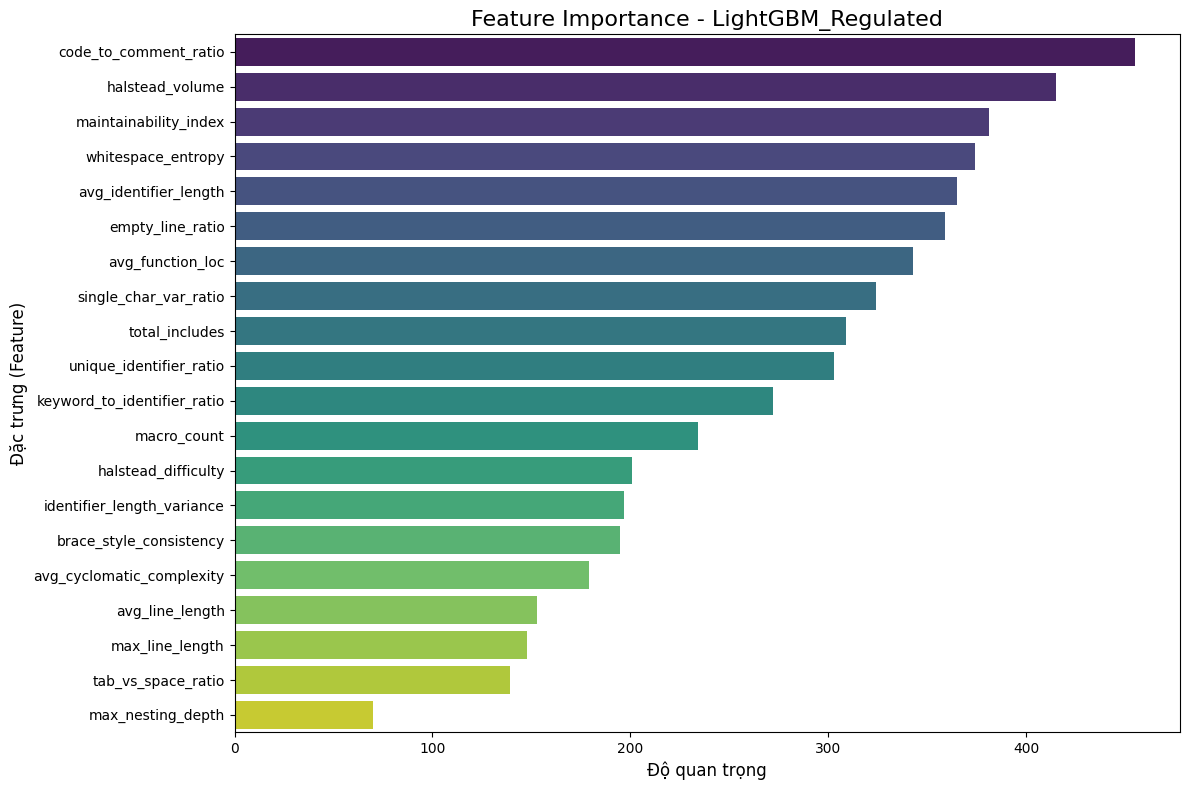

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("\n🔍 TRỰC QUAN HÓA MỨC ĐỘ QUAN TRỌNG CỦA ĐẶC TRƯNG (FEATURE IMPORTANCE)")
print("-" * 60)

# Lấy mức độ quan trọng của các đặc trưng từ mô hình đã huấn luyện
importances = final_model.feature_importances_

# Tạo DataFrame để trực quan hóa
df_importance = pd.DataFrame({
    'Feature': final_features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Vẽ biểu đồ
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=df_importance, palette='viridis')
plt.title(f'Feature Importance - {best_model_name}', fontsize=16)
plt.xlabel('Độ quan trọng', fontsize=12)
plt.ylabel('Đặc trưng (Feature)', fontsize=12)
plt.tight_layout()
plt.show()


In [ ]:
import zipfile

# Đường dẫn tới file zip trong Google Drive
zip_path = "/content/drive/MyDrive/LVTN: AI code detection/continue/test_set.zip"

# Thư mục đích: /content
extract_dir = "/content"

# Giải nén
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print("Đã giải nén xong vào:", extract_dir)


Đã giải nén xong vào: /content


In [ ]:
import zipfile

# Đường dẫn tới file zip trong Google Drive
zip_path = "/content/test.zip"

# Thư mục đích: /content
extract_dir = "/content/test-set"

# Giải nén
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print("Đã giải nén xong vào:", extract_dir)


Đã giải nén xong vào: /content/test-set


In [ ]:
import os
import glob
import pandas as pd
from tqdm.auto import tqdm

print("\n🚀 PHẦN INFERENCE: ĐÁNH GIÁ TỶ LỆ AI/HUMAN TỪNG THƯ MỤC CON CẤP THẤP NHẤT")
print("-" * 70)

# ĐƯỜNG DẪN THƯ MỤC CHA CHỨA CÁC THƯ MỤC CON
# Bạn có thể thay đổi đường dẫn này nếu cần
PARENT_DIR = "/content/test-set"
CUSTOM_THRESHOLD = 0.5

print(f"📂 Đang quét các thư mục con trong: {PARENT_DIR}")
print(f"⚙️ Threshold phân loại: {CUSTOM_THRESHOLD}\n")

summary_results = []
original_columns = X.columns

# Sử dụng os.walk để duyệt tất cả các thư mục con ở mọi cấp độ
for root, dirs, files_in_dir in os.walk(PARENT_DIR):
    # Tìm các file C/C++ nằm TRỰC TIẾP trong thư mục root hiện tại
    files = []
    for ext in ('*.c', '*.cpp', '*.C', '*.CPP','*.h','*.hpp'):
        files.extend(glob.glob(os.path.join(root, ext)))

    if not files:
        # Bỏ qua nếu thư mục hiện tại không chứa file code nào
        continue

    # Lấy tên thư mục tương đối so với PARENT_DIR để hiển thị cho đẹp
    folder_name = os.path.relpath(root, PARENT_DIR)
    print(f"\n📁 Đang xử lý thư mục: {folder_name} (Tìm thấy {len(files)} files)")

    ai_count = 0
    human_count = 0
    error_count = 0

    for file_path in tqdm(files, desc=f"Infer {os.path.basename(root)}", leave=False):
        try:
            with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
                code_raw = f.read()

            clean_code = strip_metadata_headers(code_raw)
            features = extractor.extract(clean_code)

            df_feat = pd.DataFrame([features])
            df_feat = df_feat.reindex(columns=original_columns, fill_value=0)

            scaled_feat = scaler.transform(df_feat)
            df_scaled = pd.DataFrame(scaled_feat, columns=original_columns)

            X_infer = df_scaled[final_features]

            pred_proba = final_model.predict_proba(X_infer)[0, 1]

            if pred_proba >= CUSTOM_THRESHOLD:
                ai_count += 1
            else:
                human_count += 1

        except Exception as e:
            error_count += 1

    total_processed = ai_count + human_count
    if total_processed > 0:
        ai_ratio = ai_count / total_processed
        human_ratio = human_count / total_processed
    else:
        ai_ratio = 0
        human_ratio = 0

    summary_results.append({
        "Thư mục": folder_name,
        "Tổng số file": len(files),
        "Xử lý thành công": total_processed,
        "Số file AI": ai_count,
        "Số file Human": human_count,
        "Lỗi đọc file": error_count,
        "Tỷ lệ AI": f"{ai_ratio:.2%}",
        "Tỷ lệ Human": f"{human_ratio:.2%}"
    })

# Hiển thị bảng tổng kết
df_summary = pd.DataFrame(summary_results)
if not df_summary.empty:
    print("\n📊 BẢNG TỔNG KẾT TỶ LỆ AI/HUMAN THEO TỪNG THƯ MỤC:")
    display(df_summary)
else:
    print("\n⚠️ Không tìm thấy file mã nguồn C/C++ nào trong các thư mục con.")



🚀 PHẦN INFERENCE: ĐÁNH GIÁ TỶ LỆ AI/HUMAN TỪNG THƯ MỤC CON CẤP THẤP NHẤT
----------------------------------------------------------------------
📂 Đang quét các thư mục con trong: /content/test-set
⚙️ Threshold phân loại: 0.5


📁 Đang xử lý thư mục: OOP_C++/OOP_Human-written (Tìm thấy 1565 files)


Infer OOP_Human-written:   0%|          | 0/1565 [00:00<?, ?it/s]


📁 Đang xử lý thư mục: OOP_C++/OOP_AI-Generated (Tìm thấy 1565 files)


Infer OOP_AI-Generated:   0%|          | 0/1565 [00:00<?, ?it/s]


📁 Đang xử lý thư mục: Basic_C++/Basic_C++_Human-written (Tìm thấy 1425 files)


Infer Basic_C++_Human-written:   0%|          | 0/1425 [00:00<?, ?it/s]


📁 Đang xử lý thư mục: Basic_C++/Basic_C++_AI-generated (Tìm thấy 1425 files)


Infer Basic_C++_AI-generated:   0%|          | 0/1425 [00:00<?, ?it/s]


📊 BẢNG TỔNG KẾT TỶ LỆ AI/HUMAN THEO TỪNG THƯ MỤC:


,Thư mục,Tổng số file,Xử lý thành công,Số file AI,Số file Human,Lỗi đọc file,Tỷ lệ AI,Tỷ lệ Human
0,OOP_C++/OOP_Human-written,1565,1565,52,1513,0,3.32%,96.68%
1,OOP_C++/OOP_AI-Generated,1565,1565,215,1350,0,13.74%,86.26%
2,Basic_C++/Basic_C++_Human-written,1425,1425,37,1388,0,2.60%,97.40%
3,Basic_C++/Basic_C++_AI-generated,1425,1425,439,986,0,30.81%,69.19%



🚀 PHẦN 4: KIỂM THỬ THỰC TẾ TRÊN CÁC THƯ MỤC MỚI (INFERENCE)
⚙️ Đang sử dụng Ngưỡng quyết định (Threshold): 0.5

📂 Đang quét: /content/FromAI-v1 | Expected: AI (1) | Tìm thấy 4000 file.


Xử lý FromAI-v1:   0%|          | 0/4000 [00:00<?, ?it/s]

📂 Đang quét: /content/FromAI-v2/codellama_13b | Expected: AI (1) | Tìm thấy 2000 file.


Xử lý codellama_13b:   0%|          | 0/2000 [00:00<?, ?it/s]

📂 Đang quét: /content/FromAI-v2/falcon180b | Expected: AI (1) | Tìm thấy 2000 file.


...

📂 Đang quét: /content/human/1000 code c | Expected: Human (0) | Tìm thấy 617 file.


Xử lý 1000 code c:   0%|          | 0/617 [00:00<?, ?it/s]


📊 TỔNG KẾT & TRỰC QUAN HÓA KẾT QUẢ INFERENCE
----------------------------------------------------------------------


,Thư mục,Số file,Accuracy
0,FromAI-v1,4000,96.58%
1,codellama_13b,2000,97.40%
2,falcon180b,2000,99.15%
3,falcon2-11B,2000,97.20%
4,gemini_pro,2000,96.75%
5,gemma7b,2000,95.35%
6,gpt35,2000,95.45%
7,gpt4o_mini,2000,99.45%
8,llama2-13B,2000,99.65%
9,mistral_7b,2000,99.55%



🌟 ACCURACY TỔNG THỂ (OVERALL): 97.60%


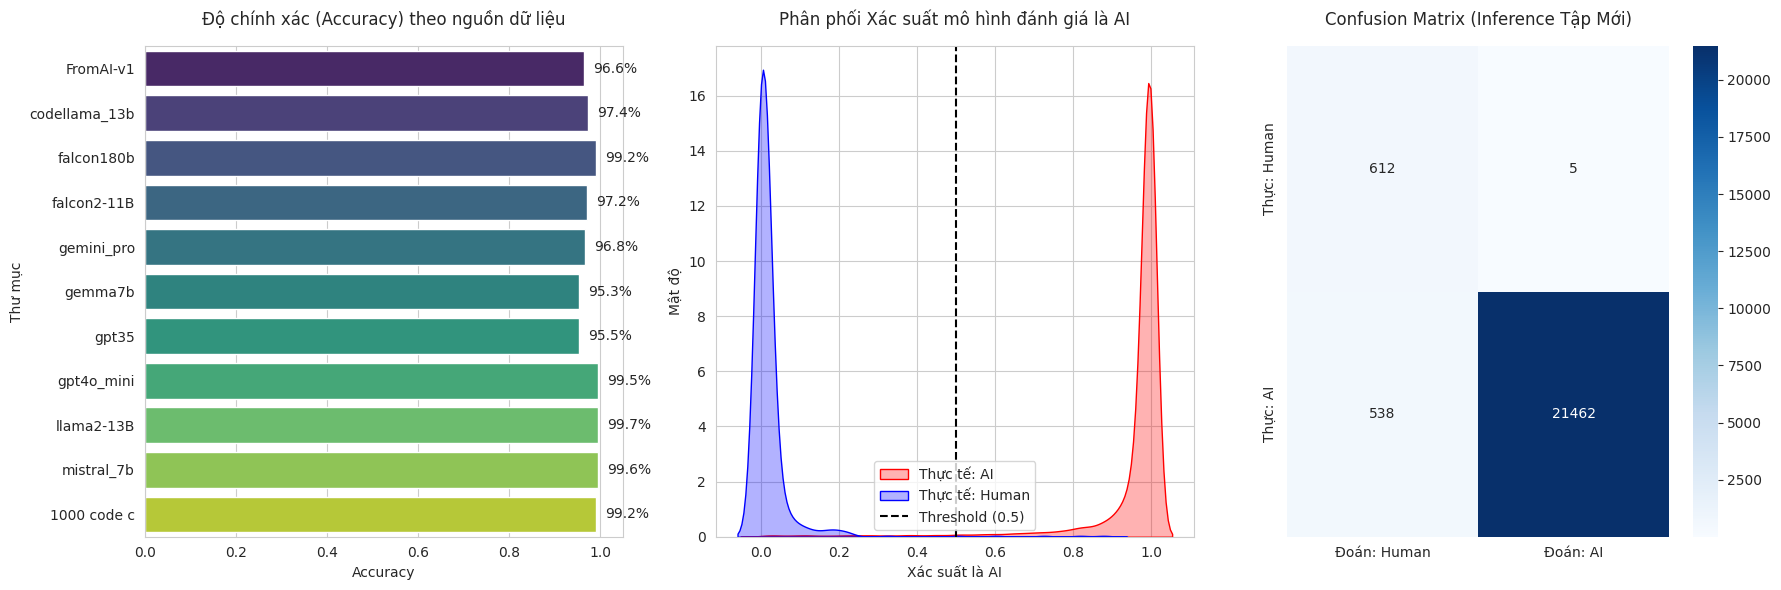


🔎 PHÂN TÍCH LỖI: Tìm thấy 543 file bị dự đoán sai. (Hiển thị ngẫu nhiên 5 file)


,Thư mục nguồn,Tên File,Nhãn thực tế (Expected),Dự đoán (Predicted),Xác suất AI
2636,FromAI-v1,FormAI_45589.cpp,AI (1),Human (0),0.255098
1152,FromAI-v1,FormAI_86128.cpp,AI (1),Human (0),0.422567
2997,FromAI-v1,FormAI_3532.cpp,AI (1),Human (0),0.089038
14918,gpt35,gpt35-30662.c,AI (1),Human (0),0.230261
10153,gemini_pro,gemini_pro-18016.c,AI (1),Human (0),0.087812


In [ ]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score, confusion_matrix

print("\n" + "="*70)
print("🚀 PHẦN 4: KIỂM THỬ THỰC TẾ TRÊN CÁC THƯ MỤC MỚI (INFERENCE)")
print("="*70)

# 1. Cấu hình các thư mục kiểm thử và nhãn thực tế (Ground Truth)
test_folders = [
    {"path": "/content/FromAI-v1", "expected": "AI (1)", "label": 1},
    {"path": "/content/FromAI-v2/codellama_13b", "expected": "AI (1)", "label": 1},
    {"path": "/content/FromAI-v2/falcon180b", "expected": "AI (1)", "label": 1},

    {"path": "/content/FromAI-v2/falcon2-11B", "expected": "AI (1)", "label": 1},
    {"path": "/content/FromAI-v2/gemini_pro", "expected": "AI (1)", "label": 1},
    {"path": "/content/FromAI-v2/gemma7b", "expected": "AI (1)", "label": 1},
    {"path": "/content/FromAI-v2/gpt35", "expected": "AI (1)", "label": 1},
    {"path": "/content/FromAI-v2/gpt4o_mini", "expected": "AI (1)", "label": 1},
    {"path": "/content/FromAI-v2/llama2-13B", "expected": "AI (1)", "label": 1},
    {"path": "/content/FromAI-v2/mistral_7b", "expected": "AI (1)", "label": 1},

    {"path": "/content/human/1000 code c", "expected": "Human (0)", "label": 0}
]

CUSTOM_THRESHOLD = 0.5
print(f"⚙️ Đang sử dụng Ngưỡng quyết định (Threshold): {CUSTOM_THRESHOLD}\n")

results = []

# Đảm bảo lấy đúng danh sách cột gốc trước khi filter để Scaler hoạt động đúng
original_columns = X.columns

for folder_info in test_folders:
    folder_path = folder_info["path"]
    expected_class = folder_info["expected"]
    true_label = folder_info["label"]

    if not os.path.exists(folder_path):
        print(f"❌ CẢNH BÁO: Không tìm thấy thư mục {folder_path}. Sẽ bỏ qua.")
        continue

    # Tìm cả file .c và .cpp (không phân biệt hoa thường nếu có thể)
    files = []
    for ext in ('*.c', '*.cpp', '*.C', '*.CPP'):
        files.extend(glob.glob(os.path.join(folder_path, ext)))

    if not files:
        print(f"⚠️ Thư mục {folder_path} trống hoặc không có file C/C++.")
        continue

    print(f"📂 Đang quét: {folder_path} | Expected: {expected_class} | Tìm thấy {len(files)} file.")

    for file_path in tqdm(files, desc=f"Xử lý {os.path.basename(folder_path)}", leave=False):
        file_name = os.path.basename(file_path)

        try:
            # Đọc file, bỏ qua các ký tự lỗi encoding (thường gặp ở code Human)
            with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
                code_raw = f.read()

            # BƯỚC 1: Xóa Metadata (Chống Leakage)
            clean_code = strip_metadata_headers(code_raw)

            # BƯỚC 2: Trích xuất Features
            features = extractor.extract(clean_code)
            df_feat = pd.DataFrame([features])

            # BƯỚC 3: Khớp cột với tập Train ban đầu, điền 0 nếu thiếu
            df_feat = df_feat.reindex(columns=original_columns, fill_value=0)

            # BƯỚC 4: Scale dữ liệu bằng Scaler đã fit ở bước trước
            scaled_feat = scaler.transform(df_feat)
            df_scaled = pd.DataFrame(scaled_feat, columns=original_columns)

            # BƯỚC 5: Lọc lấy các Feature cuối cùng (Tầng 3 L1 Lasso)
            X_infer = df_scaled[final_features]

            # BƯỚC 6: Dự đoán (Dùng Threshold)
            pred_proba = final_model.predict_proba(X_infer)[0, 1]

            if pred_proba >= CUSTOM_THRESHOLD:
                pred_label = 1
                pred_class = "AI (1)"
            else:
                pred_label = 0
                pred_class = "Human (0)"

            results.append({
                "Thư mục nguồn": os.path.basename(folder_path),
                "Tên File": file_name,
                "Nhãn thực tế (Expected)": expected_class,
                "Dự đoán (Predicted)": pred_class,
                "Xác suất AI": pred_proba,
                "True Label": true_label,
                "Pred Label": pred_label,
                "Đúng/Sai": "✅ Đúng" if true_label == pred_label else "❌ Sai"
            })

        except Exception as e:
            pass # Bỏ qua ngầm các file lỗi format quá nặng

df_results = pd.DataFrame(results)

if len(df_results) == 0:
    print("❌ Không có dữ liệu để đánh giá.")
else:
    # ==========================================
    # TRỰC QUAN HÓA BÁO CÁO KẾT QUẢ
    # ==========================================
    print("\n📊 TỔNG KẾT & TRỰC QUAN HÓA KẾT QUẢ INFERENCE")
    print("-" * 70)

    # 1. Tính Accuracy cho từng thư mục
    summary_list = []
    for folder in df_results['Thư mục nguồn'].unique():
        sub_df = df_results[df_results['Thư mục nguồn'] == folder]
        acc = accuracy_score(sub_df['True Label'], sub_df['Pred Label'])
        summary_list.append({'Thư mục': folder, 'Số file': len(sub_df), 'Accuracy': acc})

    df_summary = pd.DataFrame(summary_list)
    display(df_summary.style.format({'Accuracy': '{:.2%}'}))

    overall_acc = accuracy_score(df_results['True Label'], df_results['Pred Label'])
    print(f"\n🌟 ACCURACY TỔNG THỂ (OVERALL): {overall_acc*100:.2f}%")

    # Vẽ biểu đồ
    sns.set_style("whitegrid")
    plt.figure(figsize=(18, 6))

    # Biểu đồ 1: Accuracy theo từng nguồn sinh
    plt.subplot(1, 3, 1)
    ax = sns.barplot(x='Accuracy', y='Thư mục', data=df_summary, palette='viridis')
    plt.xlim(0, 1.05)
    plt.title('Độ chính xác (Accuracy) theo nguồn dữ liệu', fontsize=12, pad=15)
    for i, p in enumerate(ax.patches):
        ax.annotate(f"{p.get_width()*100:.1f}%", (p.get_width() + 0.02, p.get_y() + p.get_height()/2.), va='center')

    # Biểu đồ 2: Phân phối xác suất (KDE Plot)
    plt.subplot(1, 3, 2)
    sns.kdeplot(data=df_results[df_results['True Label']==1]['Xác suất AI'], label='Thực tế: AI', color='red', fill=True, alpha=0.3)
    sns.kdeplot(data=df_results[df_results['True Label']==0]['Xác suất AI'], label='Thực tế: Human', color='blue', fill=True, alpha=0.3)
    plt.axvline(CUSTOM_THRESHOLD, color='black', linestyle='--', label=f'Threshold ({CUSTOM_THRESHOLD})')
    plt.title('Phân phối Xác suất mô hình đánh giá là AI', fontsize=12, pad=15)
    plt.xlabel('Xác suất là AI')
    plt.ylabel('Mật độ')
    plt.legend()

    # Biểu đồ 3: Confusion Matrix
    plt.subplot(1, 3, 3)
    cm = confusion_matrix(df_results['True Label'], df_results['Pred Label'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Đoán: Human', 'Đoán: AI'],
                yticklabels=['Thực: Human', 'Thực: AI'])
    plt.title('Confusion Matrix (Inference Tập Mới)', fontsize=12, pad=15)

    plt.tight_layout()
    plt.show()

    # In ra 5 file dự đoán sai (nếu có) để mổ xẻ
    errors_df = df_results[df_results['Đúng/Sai'] == '❌ Sai']
    if not errors_df.empty:
        print(f"\n🔎 PHÂN TÍCH LỖI: Tìm thấy {len(errors_df)} file bị dự đoán sai. (Hiển thị ngẫu nhiên 5 file)")
        display(errors_df[['Thư mục nguồn', 'Tên File', 'Nhãn thực tế (Expected)', 'Dự đoán (Predicted)', 'Xác suất AI']].sample(min(5, len(errors_df))))

In [ ]:
import zipfile

# Đường dẫn tới file zip trong Google Drive
zip_path = "/content/cpp_100k_samples.zip"

# Thư mục đích: /content
extract_dir = "/content/cpp_100k_samples"

# Giải nén
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print("Đã giải nén xong vào:", extract_dir)


Đã giải nén xong vào: /content/cpp_100k_samples



🚀 PHẦN 4: KIỂM THỬ THỰC TẾ TRÊN CÁC THƯ MỤC MỚI (INFERENCE)
⚙️ Đang sử dụng Ngưỡng quyết định (Threshold): 0.5

📂 Đang quét: /content/cpp_100k_samples | Expected: Human (0) | Tìm thấy 100000 file.


Xử lý cpp_100k_samples:   0%|          | 0/100000 [00:00<?, ?it/s]


📊 TỔNG KẾT & TRỰC QUAN HÓA KẾT QUẢ INFERENCE
----------------------------------------------------------------------


,Thư mục,Số file,Accuracy
0,cpp_100k_samples,100000,92.54%



🌟 ACCURACY TỔNG THỂ (OVERALL): 92.54%


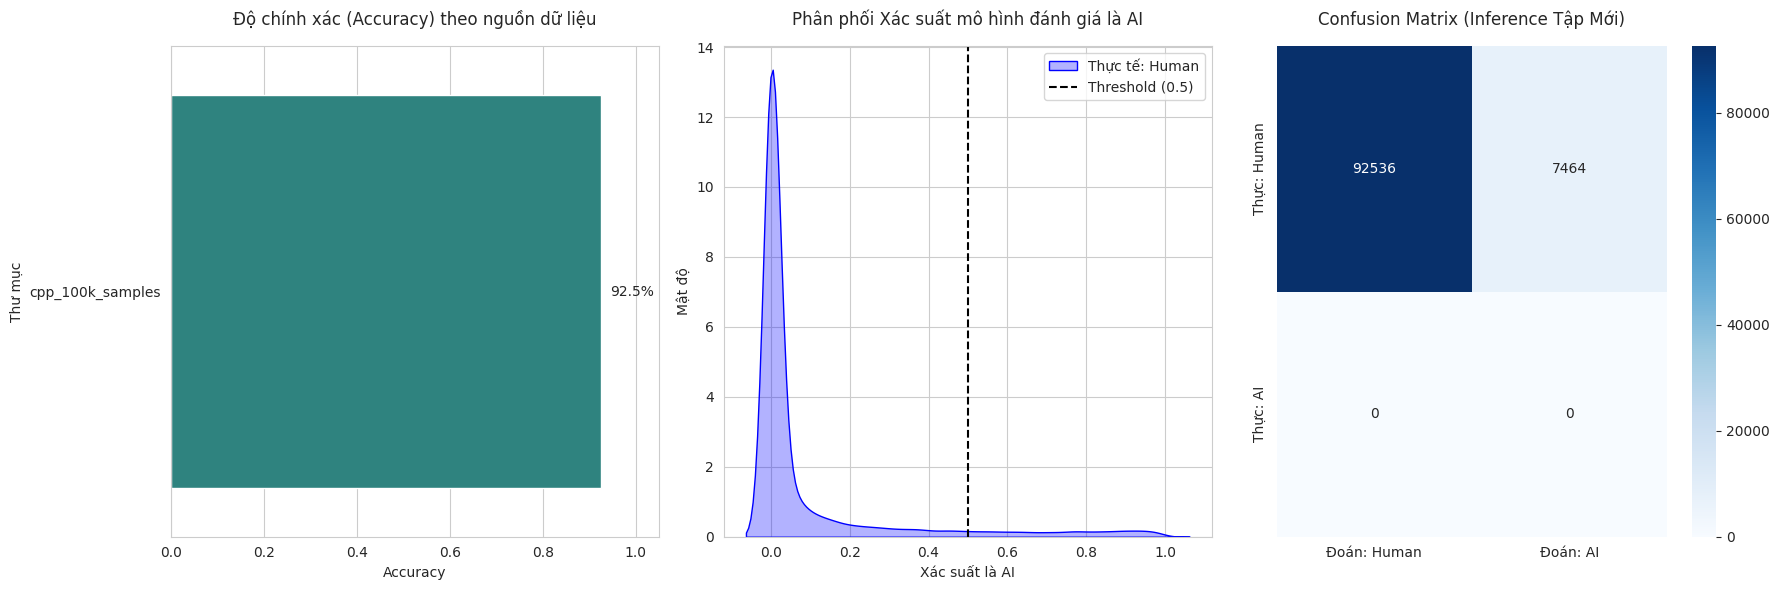


🔎 PHÂN TÍCH LỖI: Tìm thấy 7464 file bị dự đoán sai. (Hiển thị ngẫu nhiên 5 file)


,Thư mục nguồn,Tên File,Nhãn thực tế (Expected),Dự đoán (Predicted),Xác suất AI
45343,cpp_100k_samples,s673289382.cpp,Human (0),AI (1),0.991187
57929,cpp_100k_samples,s306392630.cpp,Human (0),AI (1),0.686444
46385,cpp_100k_samples,s897750145.cpp,Human (0),AI (1),0.681777
45409,cpp_100k_samples,s908628965.cpp,Human (0),AI (1),0.821901
26467,cpp_100k_samples,s892779305.cpp,Human (0),AI (1),0.914242


In [ ]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score, confusion_matrix

print("\n" + "="*70)
print("🚀 PHẦN 4: KIỂM THỬ THỰC TẾ TRÊN CÁC THƯ MỤC MỚI (INFERENCE)")
print("="*70)

# 1. Cấu hình các thư mục kiểm thử và nhãn thực tế (Ground Truth)
test_folders = [
    {"path": "/content/cpp_100k_samples", "expected": "Human (0)", "label": 0}
]

CUSTOM_THRESHOLD = 0.5
print(f"⚙️ Đang sử dụng Ngưỡng quyết định (Threshold): {CUSTOM_THRESHOLD}\n")

results = []

# Đảm bảo lấy đúng danh sách cột gốc trước khi filter để Scaler hoạt động đúng
original_columns = X.columns

for folder_info in test_folders:
    folder_path = folder_info["path"]
    expected_class = folder_info["expected"]
    true_label = folder_info["label"]

    if not os.path.exists(folder_path):
        print(f"❌ CẢNH BÁO: Không tìm thấy thư mục {folder_path}. Sẽ bỏ qua.")
        continue

    # Tìm cả file .c và .cpp (không phân biệt hoa thường nếu có thể)
    files = []
    for ext in ('*.c', '*.cpp', '*.C', '*.CPP'):
        files.extend(glob.glob(os.path.join(folder_path, ext)))

    if not files:
        print(f"⚠️ Thư mục {folder_path} trống hoặc không có file C/C++.")
        continue

    print(f"📂 Đang quét: {folder_path} | Expected: {expected_class} | Tìm thấy {len(files)} file.")

    for file_path in tqdm(files, desc=f"Xử lý {os.path.basename(folder_path)}", leave=False):
        file_name = os.path.basename(file_path)

        try:
            # Đọc file, bỏ qua các ký tự lỗi encoding (thường gặp ở code Human)
            with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
                code_raw = f.read()

            # BƯỚC 1: Xóa Metadata (Chống Leakage)
            clean_code = strip_metadata_headers(code_raw)

            # BƯỚC 2: Trích xuất Features
            features = extractor.extract(clean_code)
            df_feat = pd.DataFrame([features])

            # BƯỚC 3: Khớp cột với tập Train ban đầu, điền 0 nếu thiếu
            df_feat = df_feat.reindex(columns=original_columns, fill_value=0)

            # BƯỚC 4: Scale dữ liệu bằng Scaler đã fit ở bước trước
            scaled_feat = scaler.transform(df_feat)
            df_scaled = pd.DataFrame(scaled_feat, columns=original_columns)

            # BƯỚC 5: Lọc lấy các Feature cuối cùng (Tầng 3 L1 Lasso)
            X_infer = df_scaled[final_features]

            # BƯỚC 6: Dự đoán (Dùng Threshold)
            pred_proba = final_model.predict_proba(X_infer)[0, 1]

            if pred_proba >= CUSTOM_THRESHOLD:
                pred_label = 1
                pred_class = "AI (1)"
            else:
                pred_label = 0
                pred_class = "Human (0)"

            results.append({
                "Thư mục nguồn": os.path.basename(folder_path),
                "Tên File": file_name,
                "Nhãn thực tế (Expected)": expected_class,
                "Dự đoán (Predicted)": pred_class,
                "Xác suất AI": pred_proba,
                "True Label": true_label,
                "Pred Label": pred_label,
                "Đúng/Sai": "✅ Đúng" if true_label == pred_label else "❌ Sai"
            })

        except Exception as e:
            pass # Bỏ qua ngầm các file lỗi format quá nặng

df_results = pd.DataFrame(results)

if len(df_results) == 0:
    print("❌ Không có dữ liệu để đánh giá.")
else:
    # ==========================================
    # TRỰC QUAN HÓA BÁO CÁO KẾT QUẢ
    # ==========================================
    print("\n📊 TỔNG KẾT & TRỰC QUAN HÓA KẾT QUẢ INFERENCE")
    print("-" * 70)

    # 1. Tính Accuracy cho từng thư mục
    summary_list = []
    for folder in df_results['Thư mục nguồn'].unique():
        sub_df = df_results[df_results['Thư mục nguồn'] == folder]
        acc = accuracy_score(sub_df['True Label'], sub_df['Pred Label'])
        summary_list.append({'Thư mục': folder, 'Số file': len(sub_df), 'Accuracy': acc})

    df_summary = pd.DataFrame(summary_list)
    display(df_summary.style.format({'Accuracy': '{:.2%}'}))

    overall_acc = accuracy_score(df_results['True Label'], df_results['Pred Label'])
    print(f"\n🌟 ACCURACY TỔNG THỂ (OVERALL): {overall_acc*100:.2f}%")

    # Vẽ biểu đồ
    sns.set_style("whitegrid")
    plt.figure(figsize=(18, 6))

    # Biểu đồ 1: Accuracy theo từng nguồn sinh
    plt.subplot(1, 3, 1)
    ax = sns.barplot(x='Accuracy', y='Thư mục', data=df_summary, palette='viridis')
    plt.xlim(0, 1.05)
    plt.title('Độ chính xác (Accuracy) theo nguồn dữ liệu', fontsize=12, pad=15)
    for i, p in enumerate(ax.patches):
        ax.annotate(f"{p.get_width()*100:.1f}%", (p.get_width() + 0.02, p.get_y() + p.get_height()/2.), va='center')

    # Biểu đồ 2: Phân phối xác suất (KDE Plot)
    plt.subplot(1, 3, 2)
    sns.kdeplot(data=df_results[df_results['True Label']==1]['Xác suất AI'], label='Thực tế: AI', color='red', fill=True, alpha=0.3)
    sns.kdeplot(data=df_results[df_results['True Label']==0]['Xác suất AI'], label='Thực tế: Human', color='blue', fill=True, alpha=0.3)
    plt.axvline(CUSTOM_THRESHOLD, color='black', linestyle='--', label=f'Threshold ({CUSTOM_THRESHOLD})')
    plt.title('Phân phối Xác suất mô hình đánh giá là AI', fontsize=12, pad=15)
    plt.xlabel('Xác suất là AI')
    plt.ylabel('Mật độ')
    plt.legend()

    # Biểu đồ 3: Confusion Matrix
    plt.subplot(1, 3, 3)
    cm = confusion_matrix(df_results['True Label'], df_results['Pred Label'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Đoán: Human', 'Đoán: AI'],
                yticklabels=['Thực: Human', 'Thực: AI'])
    plt.title('Confusion Matrix (Inference Tập Mới)', fontsize=12, pad=15)

    plt.tight_layout()
    plt.show()

    # In ra 5 file dự đoán sai (nếu có) để mổ xẻ
    errors_df = df_results[df_results['Đúng/Sai'] == '❌ Sai']
    if not errors_df.empty:
        print(f"\n🔎 PHÂN TÍCH LỖI: Tìm thấy {len(errors_df)} file bị dự đoán sai. (Hiển thị ngẫu nhiên 5 file)")
        display(errors_df[['Thư mục nguồn', 'Tên File', 'Nhãn thực tế (Expected)', 'Dự đoán (Predicted)', 'Xác suất AI']].sample(min(5, len(errors_df))))

In [ ]:
import joblib
import os

# Khai báo đường dẫn lưu model trong Google Drive
save_dir = "/content/drive/MyDrive/LVTN: AI code detection/Saved_Models"
os.makedirs(save_dir, exist_ok=True)

# 1. Lưu Model
model_path = os.path.join(save_dir, f"{best_model_name}.pkl")
joblib.dump(final_model, model_path)

# 2. Lưu Scaler
scaler_path = os.path.join(save_dir, "scaler.pkl")
joblib.dump(scaler, scaler_path)

# 3. Lưu danh sách Features quan trọng (Tầng 3)
features_path = os.path.join(save_dir, "final_features.pkl")
joblib.dump(final_features, features_path)

print("💾 ĐÃ LƯU THÀNH CÔNG VÀO GOOGLE DRIVE!")
print(f"- Model   : {model_path}")
print(f"- Scaler  : {scaler_path}")
print(f"- Features: {features_path}")

💾 ĐÃ LƯU THÀNH CÔNG VÀO GOOGLE DRIVE!
- Model   : /content/drive/MyDrive/LVTN: AI code detection/Saved_Models/LightGBM_Regulated.pkl
- Scaler  : /content/drive/MyDrive/LVTN: AI code detection/Saved_Models/scaler.pkl
- Features: /content/drive/MyDrive/LVTN: AI code detection/Saved_Models/final_features.pkl


In [ ]:
# ============================================================
# EXPORT CHO HYBRID FUSION
# ============================================================
import shap
import numpy as np
import joblib
import json
import pandas as pd
from tqdm import tqdm

SAVE_DIR = '/content/drive/MyDrive/LVTN: AI code detection/Saved_Models/'
# Sử dụng file test set vừa được export ở trên
TEST_JSONL = '/content/drive/MyDrive/LVTN: AI code detection/Saved_Models/test_set_for_bert.jsonl'

print("\n🚀 ĐANG TRÍCH XUẤT ĐẶC TRƯNG VÀ DỰ ĐOÁN CHO HYBRID FUSION...")
print("-" * 60)

# --- 1. Load test set, extract features ---
with open(TEST_JSONL, 'r', encoding='utf-8') as f:
    test_dataset = [json.loads(line) for line in f]

extractor = CppFeatureExtractorV8()
test_records_features = []

for item in tqdm(test_dataset, desc="Extracting test features"):
    clean_code = strip_metadata_headers(item['code'])
    features = extractor.extract(clean_code)
    features['label'] = 1 if item['label'] == 'AI' else 0
    # Lưu file_name hoặc relative_path để làm sample_id đối chiếu với BERT
    features['sample_id'] = item.get('file_name', item.get('relative_path', 'unknown_id'))
    test_records_features.append(features)

df_test = pd.DataFrame(test_records_features).fillna(0)

sample_ids = df_test['sample_id'].values
y_true     = df_test['label'].values
X_test_raw = df_test.drop(columns=['label', 'sample_id'])

# --- 2. Load scaler + feature list đã train ---
# Ở các cell trước đã dùng joblib, nên ta tiếp tục dùng joblib
scaler = joblib.load(SAVE_DIR + 'scaler.pkl')
final_features = joblib.load(SAVE_DIR + 'final_features.pkl')
lgbm_model = joblib.load(SAVE_DIR + 'LightGBM_Regulated.pkl')

# Đảm bảo lấy đúng các cột ban đầu trước khi scale (nếu có cột thiếu thì bù 0)
X_test_raw_aligned = X_test_raw.reindex(columns=X.columns, fill_value=0)

# --- 3. Transform ---
# Scale toàn bộ features
X_test_scaled_all = scaler.transform(X_test_raw_aligned)
X_test_scaled_df = pd.DataFrame(X_test_scaled_all, columns=X.columns)

# Lọc lấy các feature cuối cùng (tầng 3)
X_test_final_infer = X_test_scaled_df[final_features]

# --- 4. Predict probs ---
lgbm_probs = lgbm_model.predict_proba(X_test_final_infer)[:, 1]  # xác suất class AI

# --- 5. SHAP values ---
explainer   = shap.TreeExplainer(lgbm_model)
shap_raw    = explainer.shap_values(X_test_final_infer)

# LightGBM binary trả về list 2 phần tử → lấy class AI (index 1)
shap_values = shap_raw[1] if isinstance(shap_raw, list) else shap_raw

# --- 6. Lưu output ---
np.save(SAVE_DIR + 'lgbm_probs_test.npy',  lgbm_probs)   # shape (N,)
np.save(SAVE_DIR + 'lgbm_shap_test.npy',   shap_values)  # shape (N, n_features)
np.save(SAVE_DIR + 'y_true_test.npy',      y_true)        # shape (N,)
np.save(SAVE_DIR + 'sample_ids_test.npy',  sample_ids, allow_pickle=True) # shape (N,) — string

# Lưu lại tên feature để chắc chắn
joblib.dump(final_features, SAVE_DIR + 'feature_names.pkl')

# --- Verify ---
print("\n✅ KẾT QUẢ XUẤT FILE CHO FUSION:")
print(f"  - lgbm_probs  : {lgbm_probs.shape}  | range [{lgbm_probs.min():.3f}, {lgbm_probs.max():.3f}]")
print(f"  - shap_values : {shap_values.shape}")
print(f"  - y_true      : {y_true.shape}  | AI={y_true.sum()}, Human={len(y_true)-y_true.sum()}")
print(f"  - sample_ids  : {len(sample_ids)} | ví dụ: {sample_ids[:2]}")
print(f"\n💾 Đã lưu thành công vào: {SAVE_DIR}")



🚀 ĐANG TRÍCH XUẤT ĐẶC TRƯNG VÀ DỰ ĐOÁN CHO HYBRID FUSION...
------------------------------------------------------------


Extracting test features: 100%|██████████| 1256/1256 [00:06<00:00, 188.24it/s]



✅ KẾT QUẢ XUẤT FILE CHO FUSION:
  - lgbm_probs  : (1256,)  | range [0.000, 1.000]
  - shap_values : (1256, 20)
  - y_true      : (1256,)  | AI=628, Human=628
  - sample_ids  : 1256 | ví dụ: ['llama2-13B-5236.c' 'so_41353287.cpp']

💾 Đã lưu thành công vào: /content/drive/MyDrive/LVTN: AI code detection/Saved_Models/
